# Mall Customers 客户分群实战

**业务背景**：商场通过客户画像自动发现不同消费群体，制定差异化营销策略。
**数据**：200 名客户，含年龄（Age）、年收入（Annual Income）、消费评分（Spending Score）
**算法**：K-Means（主模型）+ DBSCAN + 层次聚类（对比）


## 1. 环境配置


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")


环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\KMeans_DBSCAN_Hierarchical


In [2]:
DATA_DIR = "Mall_Customers-data" if os.path.exists("Mall_Customers-data") else os.path.join("KMeans_DBSCAN_Hierarchical", "Mall_Customers-data")
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"

df = pd.read_csv(os.path.join(DATA_DIR, "Mall_Customers.csv"))
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
print(f"缺失值: {df.isnull().sum().sum()}")
print(f"重复值: {df.duplicated().sum()}")
df.head()


数据形状: (200, 5)
列名: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
缺失值: 0
重复值: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. EDA（特征分布 + 收入 vs 消费散点）


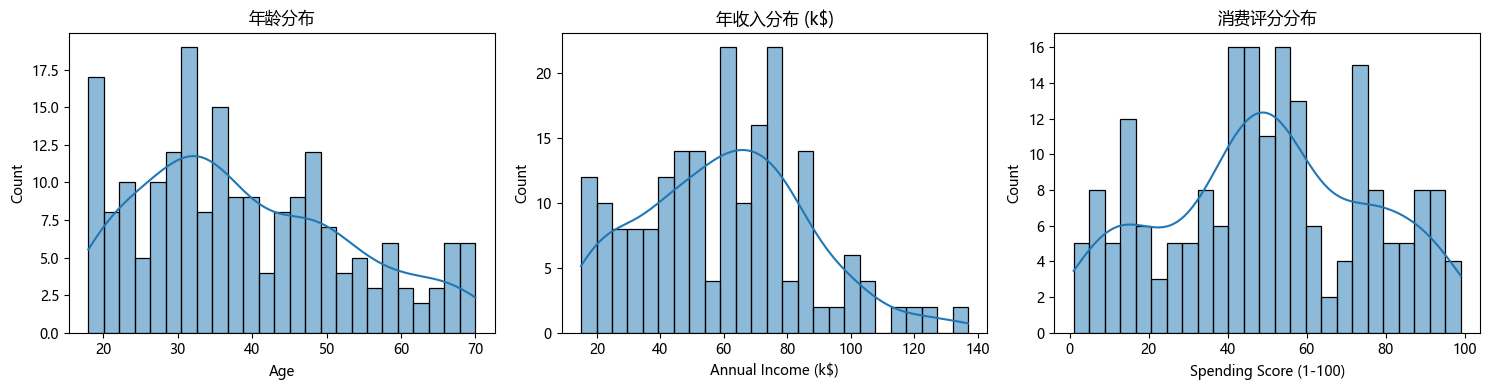

In [3]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("年龄分布")
sns.histplot(df["Annual Income (k$)"], bins=25, kde=True, ax=axes[1])
axes[1].set_title("年收入分布 (k$)")
sns.histplot(df["Spending Score (1-100)"], bins=25, kde=True, ax=axes[2])
axes[2].set_title("消费评分分布")
plt.tight_layout()
plt.show()


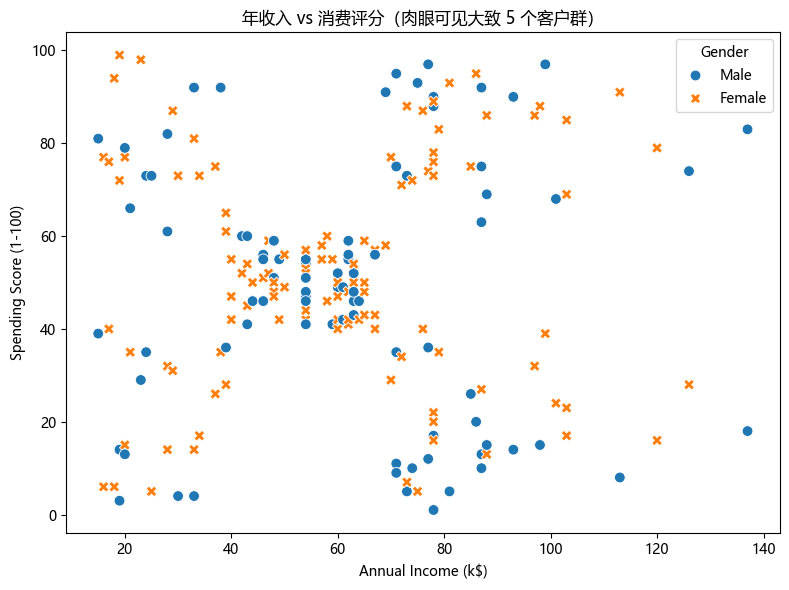

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender", style="Gender", s=60)
plt.title("年收入 vs 消费评分（肉眼可见大致 5 个客户群）")
plt.tight_layout()
plt.show()


## 3. K-Means：K 值选择（肘部法 + 轮廓系数）

- **肘部法（Elbow）**：SSE 随 K 增大而下降，找"拐点"
- **轮廓系数（Silhouette）**：样本与自身簇的紧密度 vs 与最近簇的分离度，越高越好


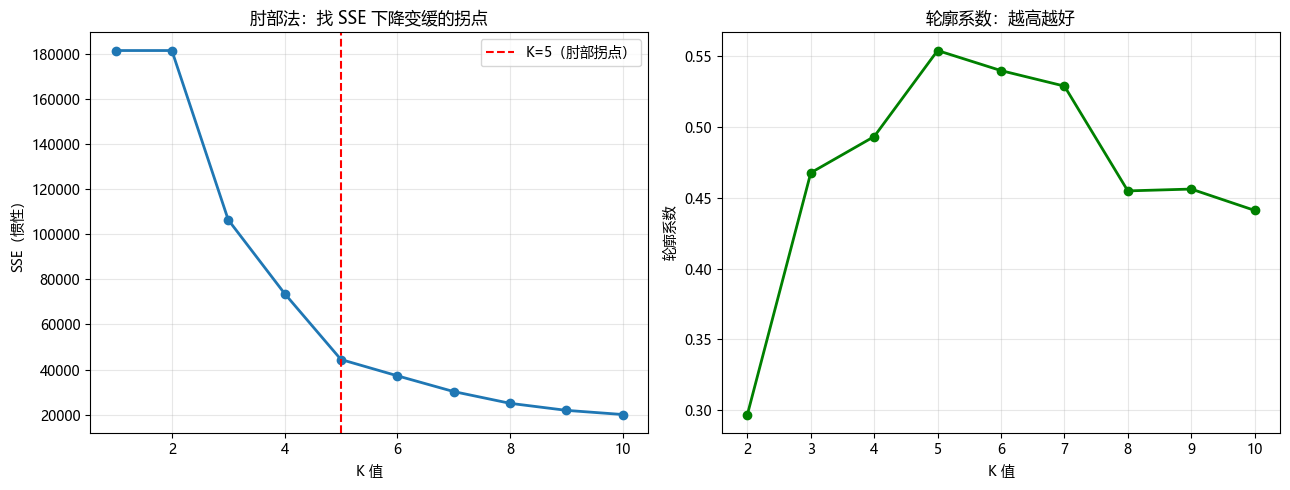

肘部法拐点约在 K=5；轮廓系数在 K=5/6 附近较高 → 选 K=5


In [5]:
X_mall = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_mall)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_mall, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, 11), [inertias[0]] + inertias, "o-", lw=2)
axes[0].axvline(5, color="red", linestyle="--", label="K=5（肘部拐点）")
axes[0].set_xlabel("K 值"); axes[0].set_ylabel("SSE（惯性）")
axes[0].set_title("肘部法：找 SSE 下降变缓的拐点")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, "o-", lw=2, color="green")
axes[1].set_xlabel("K 值"); axes[1].set_ylabel("轮廓系数")
axes[1].set_title("轮廓系数：越高越好")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("肘部法拐点约在 K=5；轮廓系数在 K=5/6 附近较高 → 选 K=5")


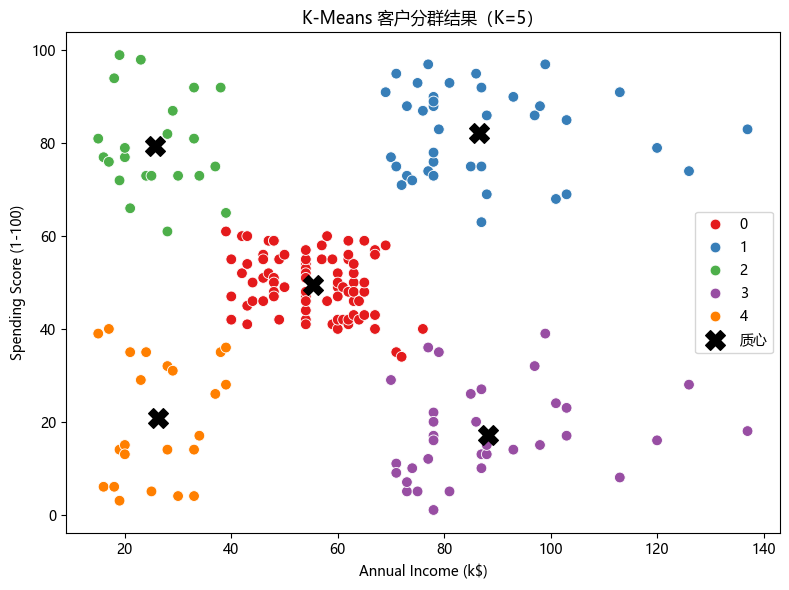

轮廓系数: 0.5539


In [6]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
df["Cluster_KMeans"] = kmeans.fit_predict(X_mall)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster_KMeans", palette="Set1", s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="X", s=200, c="black", label="质心")
plt.title("K-Means 客户分群结果（K=5）")
plt.legend()
plt.tight_layout()
plt.show()

print(f"轮廓系数: {silhouette_score(X_mall, df['Cluster_KMeans']):.4f}")


## 4. 聚类结果解读（客户群画像）


In [7]:
profile = df.groupby("Cluster_KMeans").agg(
    人数=("CustomerID", "count"),
    平均年龄=("Age", "mean"),
    平均收入=("Annual Income (k$)", "mean"),
    平均消费=("Spending Score (1-100)", "mean"),
).round(1)
profile


,人数,平均年龄,平均收入,平均消费
Cluster_KMeans,,,,
0,81,42.7000,55.3000,49.5000
1,39,32.7000,86.5000,82.1000
2,22,25.3000,25.7000,79.4000
3,35,41.1000,88.2000,17.1000
4,23,45.2000,26.3000,20.9000


In [8]:
for c in sorted(df["Cluster_KMeans"].unique()):
    sub = df[df["Cluster_KMeans"] == c]
    income = sub["Annual Income (k$)"].mean()
    spend = sub["Spending Score (1-100)"].mean()
    if income > 60 and spend > 60:
        tag = "高收入高消费：优质客户（重点维护）"
    elif income > 60 and spend <= 40:
        tag = "高收入低消费：潜力客户（刺激消费）"
    elif income <= 40 and spend > 60:
        tag = "低收入高消费：冲动消费者（谨慎风控）"
    elif income <= 40 and spend <= 40:
        tag = "低收入低消费：节约型客户（性价比推荐）"
    else:
        tag = "中等客户（标准运营）"
    print(f"簇 {c}: 人数={len(sub):3d}  平均收入={income:6.1f}k  平均消费={spend:6.1f}  → {tag}")


簇 0: 人数= 81  平均收入=  55.3k  平均消费=  49.5  → 中等客户（标准运营）
簇 1: 人数= 39  平均收入=  86.5k  平均消费=  82.1  → 高收入高消费：优质客户（重点维护）
簇 2: 人数= 22  平均收入=  25.7k  平均消费=  79.4  → 低收入高消费：冲动消费者（谨慎风控）
簇 3: 人数= 35  平均收入=  88.2k  平均消费=  17.1  → 高收入低消费：潜力客户（刺激消费）
簇 4: 人数= 23  平均收入=  26.3k  平均消费=  20.9  → 低收入低消费：节约型客户（性价比推荐）


## 5. DBSCAN 对比：同一个真实数据上表现情况

Mall 数据特征量纲差异大（收入 ~100k，消费 ~100 分），需要先标准化。
DBSCAN 不需要预设 K，但 eps 对结果非常敏感。


DBSCAN 找到簇数: 6, 噪声点: 23


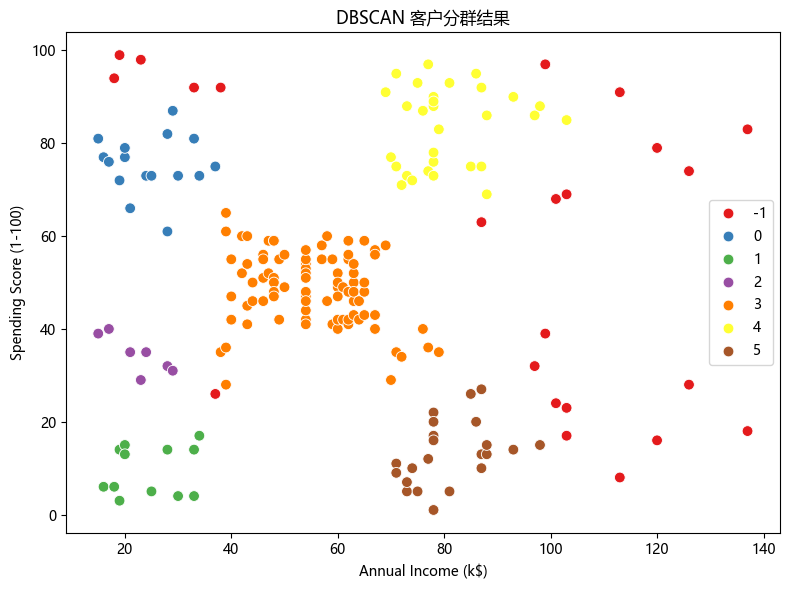

In [9]:
scaler = StandardScaler()
X_mall_scaled = scaler.fit_transform(X_mall)

dbscan_mall = DBSCAN(eps=0.35, min_samples=5)
df["Cluster_DBSCAN"] = dbscan_mall.fit_predict(X_mall_scaled)

n_clusters_db = len(set(df["Cluster_DBSCAN"])) - (1 if -1 in df["Cluster_DBSCAN"].values else 0)
n_noise = (df["Cluster_DBSCAN"] == -1).sum()
print(f"DBSCAN 找到簇数: {n_clusters_db}, 噪声点: {n_noise}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster_DBSCAN", palette="Set1", s=60)
plt.title("DBSCAN 客户分群结果")
plt.legend()
plt.tight_layout()
plt.show()


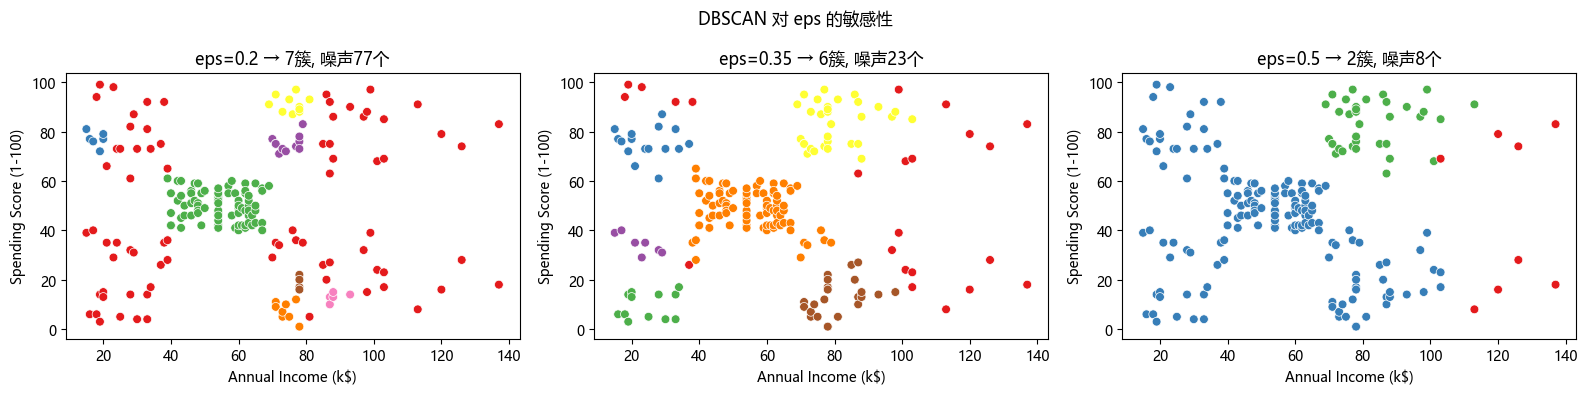

观察：eps 太小→簇被打散；eps 太大→簇被合并。DBSCAN 调参成本较高。


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, eps in enumerate([0.2, 0.35, 0.5]):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_mall_scaled)
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = (labels == -1).sum()
    sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                    hue=labels, palette="Set1", s=40, ax=axes[i], legend=False)
    axes[i].set_title(f"eps={eps} → {n_c}簇, 噪声{n_n}个")
plt.suptitle("DBSCAN 对 eps 的敏感性")
plt.tight_layout()
plt.show()

print("观察：eps 太小→簇被打散；eps 太大→簇被合并。DBSCAN 调参成本较高。")


## 6. 层次聚类：树状图 + 与 K-Means 对比


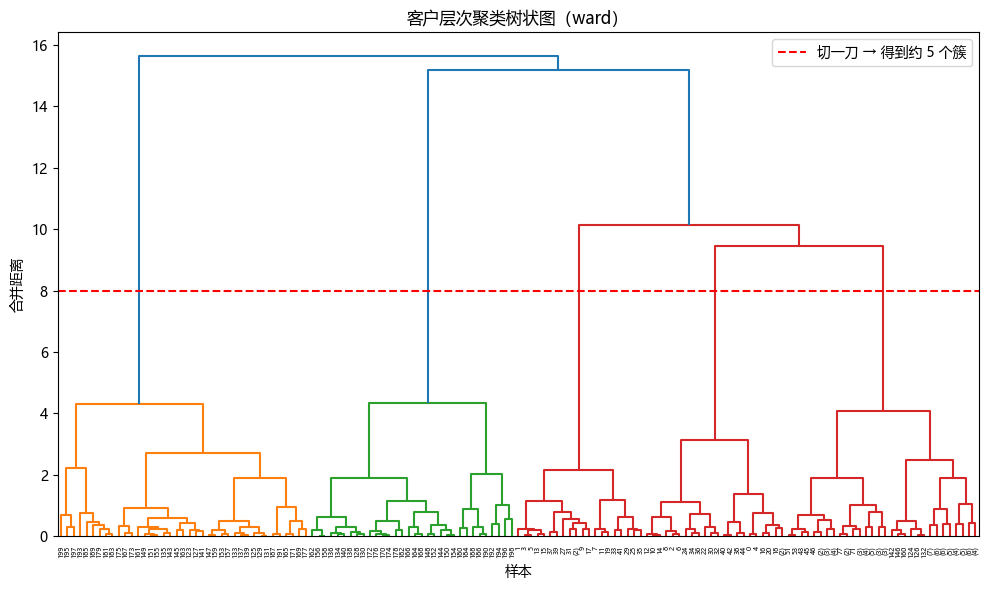

In [11]:
Z = linkage(X_mall_scaled, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode="level", p=8)
plt.axhline(y=8, color="red", linestyle="--", label="切一刀 → 得到约 5 个簇")
plt.title("客户层次聚类树状图（ward）")
plt.xlabel("样本")
plt.ylabel("合并距离")
plt.legend()
plt.tight_layout()
plt.show()


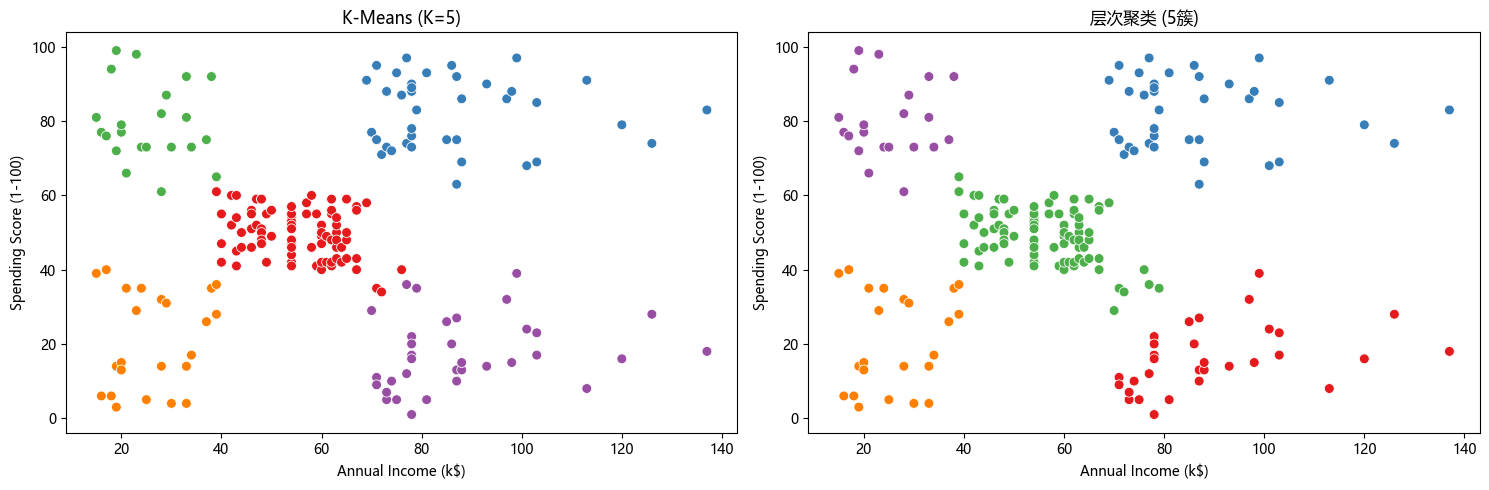

K-Means 与层次聚类的 ARI 一致性: 0.9420（越接近1越一致）


In [12]:
hier_mall = AgglomerativeClustering(n_clusters=5, linkage="ward")
df["Cluster_Hier"] = hier_mall.fit_predict(X_mall_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster_KMeans", palette="Set1", s=50, ax=axes[0], legend=False)
axes[0].set_title("K-Means (K=5)")
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster_Hier", palette="Set1", s=50, ax=axes[1], legend=False)
axes[1].set_title("层次聚类 (5簇)")
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(df["Cluster_KMeans"], df["Cluster_Hier"])
print(f"K-Means 与层次聚类的 ARI 一致性: {ari:.4f}（越接近1越一致）")


In [13]:
print("=" * 60)
print("Mall Customers 客户分群实战完成！")
print("=" * 60)
print(f"  K-Means 轮廓系数      : {silhouette_score(X_mall, df['Cluster_KMeans']):.4f}")
print(f"  DBSCAN 簇数/噪声      : {n_clusters_db}簇 / {n_noise}噪声")
print(f"  K-Means vs 层次 ARI   : {ari:.4f}")
print("=" * 60)
print("\n最终结论：")
print("  1. K-Means：需要先定 K，适合球形簇 → 在 Mall 数据上效果最好")
print("  2. DBSCAN：不需要定 K，但 Mall 这种密接团状簇易被连成一片")
print("  3. 层次聚类：可出树状图，结果与 K-Means 高度一致（ward 假设接近）")


Mall Customers 客户分群实战完成！
  K-Means 轮廓系数      : 0.5539
  DBSCAN 簇数/噪声      : 6簇 / 23噪声
  K-Means vs 层次 ARI   : 0.9420

最终结论：
  1. K-Means：需要先定 K，适合球形簇 → 在 Mall 数据上效果最好
  2. DBSCAN：不需要定 K，但 Mall 这种密接团状簇易被连成一片
  3. 层次聚类：可出树状图，结果与 K-Means 高度一致（ward 假设接近）
